In [14]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
from array import array

Goal of this particular task is to match specific hits back to truth information to add truth labels to hits, and perhaps do a better job of measuring efficiencies
Ideally, this can be tacked onto our DBCLUSTER data (or time segment data since very very similar format, so will need a DBSCLUSTER file, merged hits, ane edep-sim). Some of this has already been looked at by me in the 7/13 notebook so a lot of shared code. 

In [15]:
#Import needed files
DBSCAN_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2530.npz')
dbscan_hits = DBSCAN_file['first']

merged_hits_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/mulithit_detector_sim_lossy_2530.npz')
merged_hits_array = merged_hits_file['first']
n_neutrino_events = merged_hits_file['second']

f = root.TFile.Open("/sdf/data/neutrino/summer25/tanaka/nd-production/run-spill-build/MicroProdN4p1_NDComplex_FHC.spill.full/EDEPSIM_SPILLS/0002000/0002500/MicroProdN4p1_NDComplex_FHC.spill.full.0002530.EDEPSIM_SPILLS.root")
edep_events = f.Get("EDepSimEvents")
# Set the branch address.
event = root.TG4Event()
edep_events.SetBranchAddress("Event",root.AddressOf(event))
print("loaded")

loaded


In [16]:
#total neutrino events in the file.
n_entries = edep_events.GetEntries()
print(n_entries)

5838


In [4]:
tms_hits = []
for i in range(edep_events.GetEntries()):
    edep_events.GetEntry(i)
    event_hit_segments = event.SegmentDetectors['volTMS']
    tms_hits.append(event_hit_segments.size())
    
    

In [5]:
np.argmax(tms_hits)

np.int64(3062)

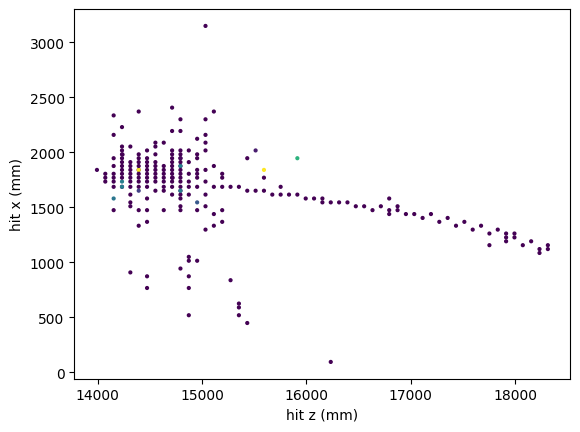

In [17]:
#For context, here is the neutrino event we are dealing with.
neutrino_number = 3062
event_merged_hits = merged_hits_array[merged_hits_array[:,0] == neutrino_number ]
hit_xs = event_merged_hits[:,2]
hit_zs = event_merged_hits[:,4]
hit_ts = event_merged_hits[:,5]
hit_PEs = event_merged_hits[:,6]
plt.scatter(hit_zs, hit_xs, s = 4, c = hit_ts, cmap = 'viridis')
plt.xlabel("hit z (mm)")
plt.ylabel("hit x (mm)")
plt.show()
hit_numbers = event_merged_hits[:,1]

In [5]:
#Note, some hit segments have 2 trackids associated with them. This is a known weirdness with edep-sim. Will check with dan if there has been a resolution and for now just take the first.
edep_events.GetEntry(neutrino_number)
event_hit_segments = event.SegmentDetectors['volTMS']
trackid_dict = {} #stores hit number trackid pair. (hit # : trackid)
for hit_number in hit_numbers:
    hit_segment = event_hit_segments[int(hit_number)]
    contrib_vector = hit_segment.Contrib
    trackid_dict[int(hit_number)] = contrib_vector[0] #just pulling trackid of first contributor to segment 


In [6]:
#Now lets crack open the trajectories list. Prob makes most sense to make a dictionary keyed by trackid.
#big for the program, the Trajectories is ordered by track id, so can just index!
pdgid_dict = {} #(trackid : pdgid)
event_trajectories = event.Trajectories
for trackid in trackid_dict.values():
    pdgid = event_trajectories[trackid].GetPDGCode()
    pdgid_dict[trackid] = pdgid

#now create a different dictionary - call it info dict. looks like (hit # : (trackid, pdgid) ). 
hit_info_dict = {}
for hit_number in hit_numbers:
    hit_trackid = trackid_dict[hit_number]
    hit_pdgid = pdgid_dict[hit_trackid]
    hit_info_dict[int(hit_number)] = (hit_trackid, hit_pdgid)


#Let's experiment with adding this information on to our hits. 
rows = []
for hit_number in event_merged_hits[:,1]:
    row = event_merged_hits[event_merged_hits[:,1] == hit_number][0]
    hit_info = hit_info_dict[int(hit_number)]
    addition = np.array((hit_info[0], hit_info[1]))
    new_row = np.hstack((row, addition))
    rows.append(new_row)
merged_hits_with_info = np.vstack(rows)
#ok so it really is not that hard to add this sort of information to all our hits. Now we have columsn for trackid as well as pdgid. 

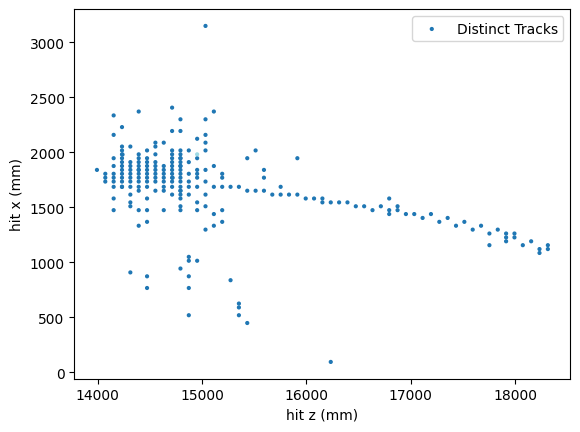

In [7]:
#For context, here is the neutrino event we are dealing with.
hit_xs = merged_hits_with_info[:,2]
hit_zs = merged_hits_with_info[:,4]
hit_ts = merged_hits_with_info[:,5]
hit_PEs = merged_hits_with_info[:,6]
hit_pdgid = merged_hits_with_info[:,-1]
hit_trackid = merged_hits_with_info[:,-2]
plt.scatter(hit_zs, hit_xs, s = 4, c = hit_pdgid, cmap = 'tab20', label = 'Distinct Tracks')
plt.xlabel("hit z (mm)")
plt.ylabel("hit x (mm)")
plt.legend()
plt.show()
hit_numbers = event_merged_hits[:,1]

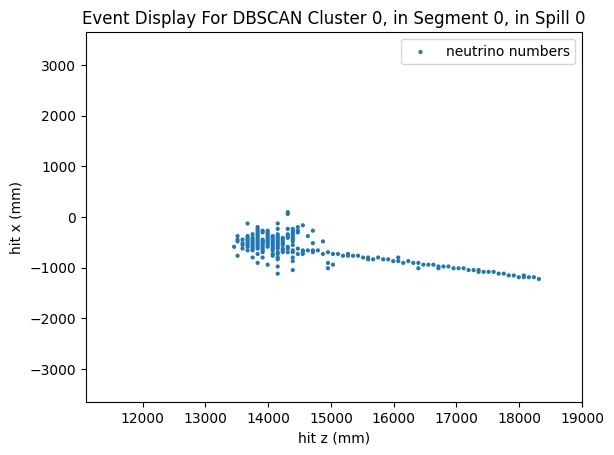

In [18]:
#So this stuff is all general proof of concept material. Let's grab a few of our DBSCANNED fellas and apply a very simple semantic mask. Will require us to create a few function
#One doesn't really want to regenerate our dictionaries every time we loop over hits. Could be advantageous to first scan for unique neutrino numbers
#for some context, lets see if I can rattle off the current contents of a dbscanned hit, this array of numbers
# nn / hn / x / y / z / t / PE / orient / true spill / rec spill / time segment / dbscan cluster
spill_number = 0
time_segment_number = 0
cluster_number = 0

spill_level = dbscan_hits[dbscan_hits[:,-4] == spill_number]
time_segment_level = spill_level[spill_level[:,-2] == time_segment_number]
dbscan_cluster_level = time_segment_level[time_segment_level[:,-1] == cluster_number]

hit_xs = dbscan_cluster_level[:,2]
hit_zs = dbscan_cluster_level[:,4]
hit_ts = dbscan_cluster_level[:,5]
hit_nns = dbscan_cluster_level[:,0]
plt.scatter(hit_zs, hit_xs, s = 4, c = hit_nns, cmap = 'tab10', label = "neutrino numbers")
plt.xlabel("hit z (mm)")
plt.ylabel("hit x (mm)")
plt.xlim((11100,19000))
plt.ylim((-3650,3650))
plt.title(f"Event Display For DBSCAN Cluster {cluster_number}, in Segment {time_segment_number}, in Spill {spill_number}")
plt.legend()
plt.show()

In [19]:
#first lets grab the neutrino numbers
nns_in_cluster = np.unique(dbscan_cluster_level[:,0])
dbscan_dict = {} #holds the hit info dictionary for a given event. 
for nn in nns_in_cluster:
    event_merged_hits = merged_hits_array[merged_hits_array[:,0] == nn ]
    hit_numbers = event_merged_hits[:,1]
    edep_events.GetEntry(int(nn))
    event_hit_segments = event.SegmentDetectors['volTMS']
    trackid_dict = {} #stores hit number trackid pair. (hit # : trackid)
    
    for hit_number in hit_numbers:
        hit_segment = event_hit_segments[int(hit_number)]
        contrib_vector = hit_segment.Contrib
        trackid_dict[int(hit_number)] = contrib_vector[0] #just pulling trackid of first contributor to segment 

    pdgid_dict = {} #(trackid : pdgid)
    event_trajectories = event.Trajectories
    for trackid in trackid_dict.values():
        pdgid = event_trajectories[trackid].GetPDGCode()
        pdgid_dict[trackid] = pdgid

    #now create a different dictionary - call it info dict. looks like (hit # : (trackid, pdgid) ). 
    hit_info_dict = {}
    for hit_number in hit_numbers:
        hit_trackid = trackid_dict[hit_number]
        hit_pdgid = pdgid_dict[hit_trackid]
        hit_info_dict[int(hit_number)] = (hit_trackid, hit_pdgid)

    dbscan_dict[int(nn)] = hit_info_dict


#I would like to see a mask that categorizes by neutrino event that originated in the tms vs one that didn't. Not sure how useful this will be but could be interesting. 
edep_detsim = f.Get("DetSimPassThru") #grab detsim, should contain the gRooTracker
tracker_tree = edep_detsim.gRooTracker 
nns_in_cluster = np.unique(dbscan_cluster_level[:,0])

edep_true_neutrino_vtx = [] 
vtxs = array('d', [0.0]*5) 
tracker_tree.SetBranchAddress("EvtVtx", vtxs)
neutrino_vtxs_info = {}
for i in range(tracker_tree.GetEntries()):
    tracker_tree.GetEntry(i)
    #don't forget to scale positions (tracker inexplicably uses m)
    x = vtxs[0]*1000
    y = vtxs[1]*1000
    z = vtxs[2]*1000
    in_tms = 0 #default is not in the tms
    if (11185 <= z <= 18535): #check if in z range of tms
        if (-3730 <= x <= 3730): #check if in x range of tms (?)
            if (-2350 <= y <= 2350): #check if in y range of tms (?)
                in_tms = 1
    neutrino_vtxs_info[i] = (vtxs[0]*1000,vtxs[1]*1000,vtxs[2]*1000, in_tms) #x, y, z, in_tms (0 if false, 1 if true)
                
    
#now we can imagine adding the information row by row to our dbcluster. 
rows = []
for hit in dbscan_cluster_level:
    nn = hit[0]
    hn = hit[1]
    hit_info = (dbscan_dict[nn])[hn] #grabbing relevant hit information. 
    hit_trackid, hit_pdgid = hit_info
    in_tms = (neutrino_vtxs_info[int(nn)])[3]
    addition = np.array((hit_trackid, hit_pdgid, in_tms))
    new_row = np.hstack((hit, addition))
    rows.append(new_row)
    
dbscan_hits_with_info = np.vstack(rows)

/lscratch/ktwall/tmp/ipykernel_1080125/745913271.py:78: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc1 = ax1.scatter(hit_zs, hit_xs, s = 4, c = hit_colors_by_pdgid , cmap = 'tab10')


Text(0, 0.5, 'Hit X (mm)')

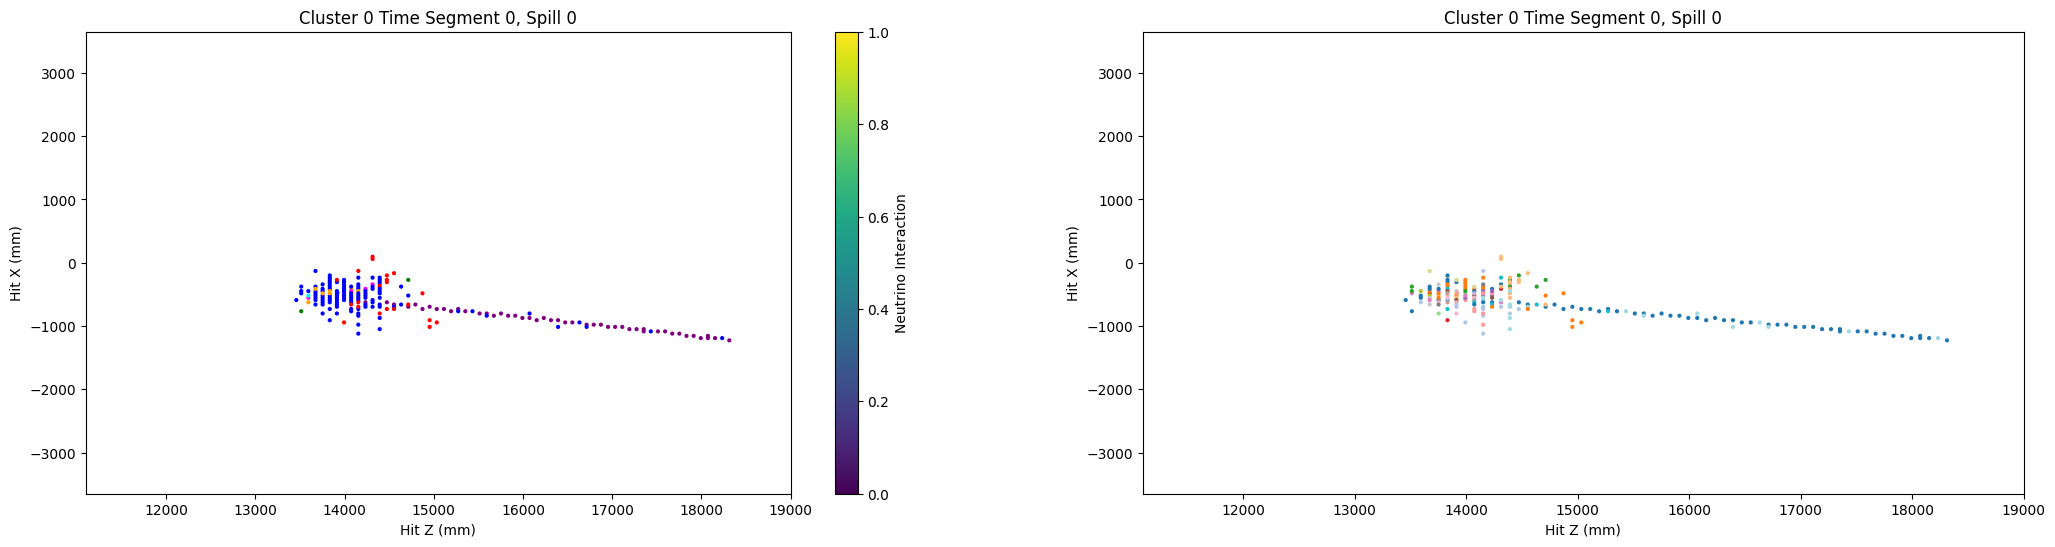

In [21]:
#plot it!
hit_xs = dbscan_hits_with_info[:,2]
hit_zs = dbscan_hits_with_info[:,4]
hit_ts = dbscan_hits_with_info[:,5]
hit_PEs = dbscan_hits_with_info[:,6]
hit_nns = dbscan_hits_with_info[:,0]
hit_trackids = dbscan_hits_with_info[:,-3]
hit_pdgids = dbscan_hits_with_info[:,-2]
hit_tms_state = dbscan_hits_with_info[:,-1]

def hitcolor(pdgid):
    c = 'black' # black track by default
    if pdgid == 2212:
        c = 'red' # proton == red
    if pdgid == 2112:
        c = 'green' # neutron == green
    if pdgid == 211:
        c = 'magenta' # pi+ == magenta
    if pdgid == -211:
        c = 'cyan' # pi- == cyan
    if pdgid == 22:
        c = 'gold' # photon == gold
    if pdgid == 13:
        c = 'purple' # muon == purple
    if pdgid == -13:
        c = 'lightcoral' # anti-muon = coral
    if pdgid == 11:
        c = 'blue' # electron == blue
    if pdgid == -11:
        c = 'orange' # positron == orange
    return c    

hit_colors_by_pdgid = []
for pdgid_ in hit_pdgids:
    color = hitcolor(pdgid_)
    hit_colors_by_pdgid.append(color)

#A simple semantic mask, muons and all else. 
muon_semantic_mask = []
for pdgid_ in hit_pdgids:
    if pdgid_ == 13 or pdgid_ == -13:
        muon_semantic_mask.append('purple')
    else:
        muon_semantic_mask.append('black')

shower_semantic_mask = []
for pdgid_ in hit_pdgids:
    if pdgid_ == 11 or pdgid_ == -11 or pdgid_ == 22:
        shower_semantic_mask.append('red')
    else:
        shower_semantic_mask.append('black')

in_tms_mask = []
for state in hit_tms_state:
    if state == 1:
        in_tms_mask.append('green')
    else:
        in_tms_mask.append('black')

combined_semantic_mask = []
for i in range(len(hit_tms_state)):
    if (hit_pdgids[i] == 13 or hit_pdgids[i] == -13): #muon or antimuon?
        if hit_tms_state[i] == 1: 
            combined_semantic_mask.append('purple') #muon from interaction in TMS
        else:
            combined_semantic_mask.append('blue') #muon from interaction outside of the TMS
    else:
        if hit_tms_state[i] == 1: 
            combined_semantic_mask.append('red') #other from interaction in TMS
        else:
            combined_semantic_mask.append('green') #other from interaction outside of the TMS 
        



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 6))

sc1 = ax1.scatter(hit_zs, hit_xs, s = 4, c = hit_colors_by_pdgid , cmap = 'tab10')
fig.colorbar(sc1, ax=ax1, label = 'Neutrino Interaction')
ax1.set_title(f"Cluster {cluster_number} Time Segment {time_segment_number}, Spill {spill_number}")
ax1.set_xlim((11100,19000))
ax1.set_ylim((-3650,3650))
ax1.set_xlabel("Hit Z (mm)")
ax1.set_ylabel("Hit X (mm)")

sc2 = ax2.scatter(hit_zs, hit_xs, s = 4, c = hit_trackids, cmap = 'tab20')
ax2.set_title(f"Cluster {cluster_number} Time Segment {time_segment_number}, Spill {spill_number}")
ax2.set_xlim((11100,19000))
ax2.set_ylim((-3650,3650))
ax2.set_xlabel("Hit Z (mm)")
ax2.set_ylabel("Hit X (mm)")


In [15]:
#Generate a dictionary for the whole file at the top, more memory efficient 
nns_in_file = np.unique(dbscan_hits[:,0])
dbscan_file_dict = {} #holds the hit info dictionary for a given event. 
for nn in nns_in_file:
    event_merged_hits = merged_hits_array[merged_hits_array[:,0] == nn ]
    hit_numbers = event_merged_hits[:,1]
    edep_events.GetEntry(int(nn))
    event_hit_segments = event.SegmentDetectors['volTMS']
    trackid_dict = {} #stores hit number trackid pair. (hit # : trackid)
    
    for hit_number in hit_numbers:
        hit_segment = event_hit_segments[int(hit_number)]
        contrib_vector = hit_segment.Contrib
        trackid_dict[int(hit_number)] = contrib_vector[0] #just pulling trackid of first contributor to segment 

    pdgid_dict = {} #(trackid : pdgid)
    event_trajectories = event.Trajectories
    for trackid in trackid_dict.values():
        pdgid = event_trajectories[trackid].GetPDGCode()
        pdgid_dict[trackid] = pdgid

    #now create a different dictionary - call it info dict. looks like (hit # : (trackid, pdgid) ). 
    hit_info_dict = {}
    for hit_number in hit_numbers:
        hit_trackid = trackid_dict[hit_number]
        hit_pdgid = pdgid_dict[hit_trackid]
        hit_info_dict[int(hit_number)] = (hit_trackid, hit_pdgid)

    dbscan_file_dict[int(nn)] = hit_info_dict

In [16]:
#Lets do the same thing, but now looping over clusters. 
#spill_number = 0
#time_segment_number = 70
#cluster_number = 0

#a nest loop that gets down to the level of dbscan_cluster_level hits. 
dbscan_cluster_list = []
spills_in_file = np.unique(dbscan_hits[:,-4])
for spill_number in spills_in_file:
    spill_level = dbscan_hits[dbscan_hits[:,-4] == spill_number]
    segments_in_spill = np.unique(spill_level[:,-2])
    for segment_number in segments_in_spill:
        time_segment_level = spill_level[spill_level[:,-2] == segment_number]
        clusters_in_segment = np.unique(time_segment_level[:,-1])
        for cluster_number in clusters_in_segment:
            dbscan_cluster_level = time_segment_level[time_segment_level[:,-1] == cluster_number]
            rows = []
            for hit in dbscan_cluster_level:
                nn = hit[0]
                hn = hit[1]
                hit_info = (dbscan_file_dict[nn])[hn] #grabbing relevant hit information. 
                hit_trackid, hit_pdgid = hit_info
                in_tms = (neutrino_vtxs_info[int(nn)])[3]
                addition = np.array((hit_trackid, hit_pdgid, in_tms))
                new_row = np.hstack((hit, addition))
                rows.append(new_row)
    
            dbscan_hits_with_info = np.vstack(rows)
            dbscan_cluster_list.append(dbscan_hits_with_info)

#file_array_with_info = np.vstack(file_hits_with_info)
            
            
            

In [17]:
#A test dbscan cluster --> graph input ( x, z, PE , label)
def GraphPrep(dbscan_cluster_list_, ): #input, a list of the dbscan cluster hits, 
    number_of_clusters = len(dbscan_cluster_list_)
    formatted_clusters = [] #list of arrays containing clusters w properly formatted hits / nodes. 
    for i in range(number_of_clusters):
        hits_in_cluster = dbscan_cluster_list_[i]
        n_hits_in_cluster = len(hits_in_cluster) 
        #If we have less than 3 hits in our cluster cannot properly use Delaunay triangulation algorithm, so drop cluster. Lossy!
        if n_hits_in_cluster < 3:
            continue
        #lets do a muon or non-muon semantic label. Muon/AntiMuon gets 1, else gets a 0
        nodes = []
        for hit in hits_in_cluster:
            nn = hit[0]
            x = hit[2]
            z = hit[4]
            PE = hit[6]
            pdgid = hit[-2] # hit pdgid
            in_tms = hit[-1] # did neutrino interaction which produced the hit occur in the TMS or outside?
            label = 0 
            if (pdgid == 13 or pdgid == -13): #hit caused by a muon
                if (in_tms == 1): #caused by a neutrino interaction from inside the TMS
                    label = 1 #muon caused by an interaction inside the TMS
                else:
                    label = 2 #muon caused by an interaction outside the TMS
            else:
                if (in_tms == 1):
                    label = 3 #other caused by an interaction from inside the TMS
                else:
                    label = 4 #other caused by an interaction outside the TMS
                
                
            nodes.append(np.array((x,z,PE,label)))

        formatted_clusters.append(np.vstack((nodes)))

    return(formatted_clusters)
        

In [18]:
graph_points_list = GraphPrep(dbscan_cluster_list) #this is a list of arrays. Each array row corresponds to 1 node, and the full array corresponds to a graph (in theory). This runs pretty damn quick. 

In [22]:
graph_points_list[0]

array([[-5.54422606e+02,  1.64730000e+04,  6.82709593e+00,
         4.00000000e+00],
       [-5.92221923e+01,  1.51930000e+04,  4.93758866e+01,
         3.00000000e+00],
       [ 2.36079483e+02,  1.23030000e+04,  3.34621683e+01,
         4.00000000e+00],
       [ 1.65336567e+02,  1.23030000e+04,  2.78424553e+01,
         2.00000000e+00],
       [ 1.12036594e+03,  1.23580000e+04,  7.69070237e+00,
         4.00000000e+00],
       [ 1.15573739e+03,  1.23580000e+04,  3.17813745e+00,
         4.00000000e+00],
       [ 2.71450941e+02,  1.25230000e+04,  6.87122321e+00,
         4.00000000e+00],
       [ 1.15573739e+03,  1.19730000e+04,  1.07186396e+01,
         4.00000000e+00],
       [ 1.04962302e+03,  1.19730000e+04,  2.04647571e+01,
         4.00000000e+00],
       [-4.48308232e+02,  1.24680000e+04,  1.38637468e+01,
         4.00000000e+00]])